In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.metrics import mean_squared_error

In [ ]:
# Set up the environment
np.random.seed(42)
plt.style.use('default')

In [ ]:
def generate_speech_signal(duration=2.0, fs=44100):
    """Generate synthetic speech signal (NO AUDIO FILE NEEDED!)"""
    t = np.linspace(0, duration, int(fs * duration))

    # Create speech-like signal with formants (vowel /a/)
    f1, f2, f3 = 700, 1220, 2600  # Formant frequencies
    pitch = 120  # Fundamental frequency

    # Generate harmonic series with formant shaping
    speech = np.zeros(len(t))
    for harmonic in range(1, 20):  # First 20 harmonics
        freq = pitch * harmonic
        if freq < fs/2:  # Below Nyquist frequency
            # Apply formant amplification
            amp = 1.0 / harmonic  # Natural harmonic decay
            if abs(freq - f1) < 100: amp *= 3  # F1 boost
            elif abs(freq - f2) < 150: amp *= 2  # F2 boost
            elif abs(freq - f3) < 200: amp *= 1.5  # F3 boost

            speech += amp * np.sin(2 * np.pi * freq * t)

    # Add pitch variation and envelope
    pitch_mod = np.sin(2 * np.pi * 2 * t)  # Pitch modulation
    envelope = np.exp(-t/4)  # Decay envelope
    speech *= (1 + 0.1 * pitch_mod) * envelope

    # Normalize
    speech = speech / np.max(np.abs(speech))
    return t, speech


📊 (1a) Generating and plotting original speech signal...


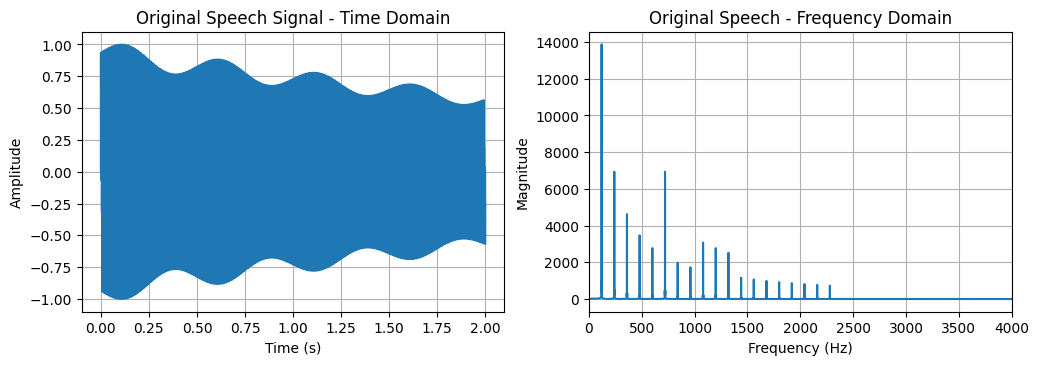

In [ ]:
# (1a) Generate and plot original speech signal
print("\n📊 (1a) Generating and plotting original speech signal...")
time_orig, speech_orig = generate_speech_signal()
fs_orig = 44100

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(time_orig, speech_orig)
plt.title('Original Speech Signal - Time Domain')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Frequency domain
freq_orig = np.fft.fftfreq(len(speech_orig), 1/fs_orig)
X_orig = np.fft.fft(speech_orig)
plt.subplot(2, 2, 2)
plt.plot(freq_orig[:len(freq_orig)//2], np.abs(X_orig[:len(X_orig)//2]))
plt.title('Original Speech - Frequency Domain')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 4000)
plt.grid(True)

🔢 (1b & 1c) Sampling at different rates...


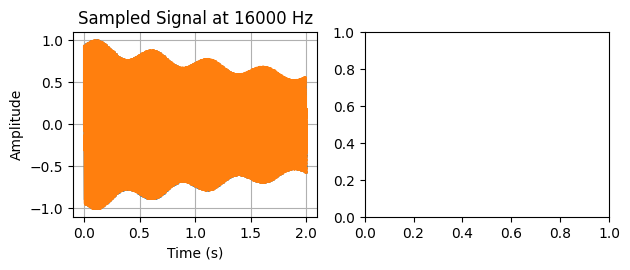

In [ ]:
# (1b & 1c) Sample at different rates and plot
print("🔢 (1b & 1c) Sampling at different rates...")
sampling_rates = [8000, 16000, 44100]
sampled_signals = {}

for i, fs_new in enumerate(sampling_rates):
    if fs_new < fs_orig:
        downsample_factor = fs_orig // fs_new
        sampled = speech_orig[::downsample_factor]
        time_sampled = np.linspace(0, 2.0, len(sampled))
    else:
        sampled = speech_orig
        time_sampled = time_orig

    sampled_signals[fs_new] = (time_sampled, sampled)

    # Plot sampled signal
    plt.subplot(2, 2, 3 if i < 2 else 4)
    if i < 2:
        plt.plot(time_sampled, sampled, 'o-', markersize=1, label=f'{fs_new}Hz')
        plt.title(f'Sampled Signal at {fs_new} Hz')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.grid(True)

plt.tight_layout()
plt.show()


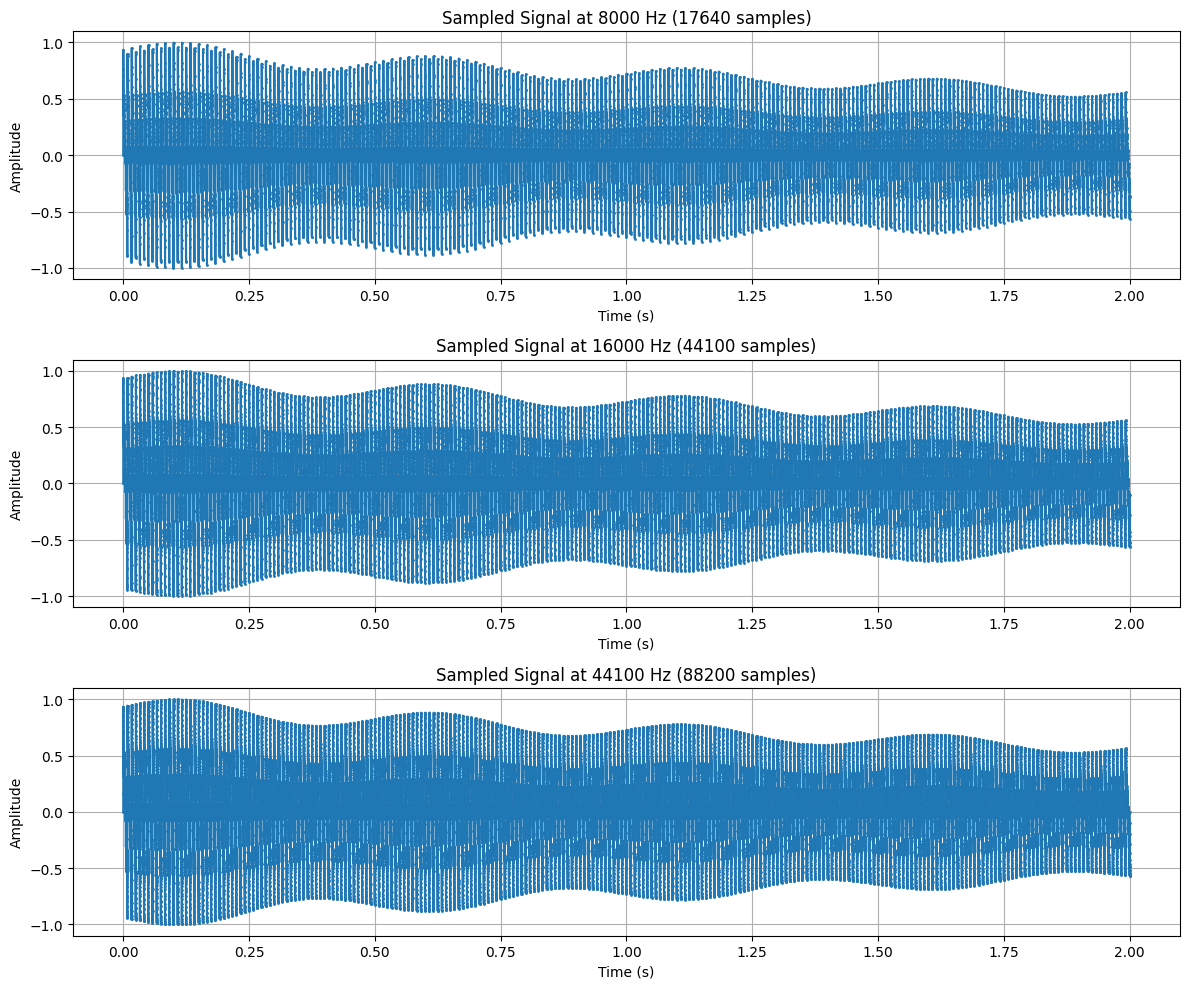

In [ ]:
# Plot all sampled signals together
plt.figure(figsize=(12, 10))
for i, (fs_new, (time_s, signal_s)) in enumerate(sampled_signals.items()):
    plt.subplot(3, 1, i+1)
    plt.plot(time_s, signal_s, 'o-', markersize=1)
    plt.title(f'Sampled Signal at {fs_new} Hz ({len(signal_s)} samples)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.tight_layout()
plt.show()

🔄 (1d) Reconstructing signals using ZOH and Linear interpolation...


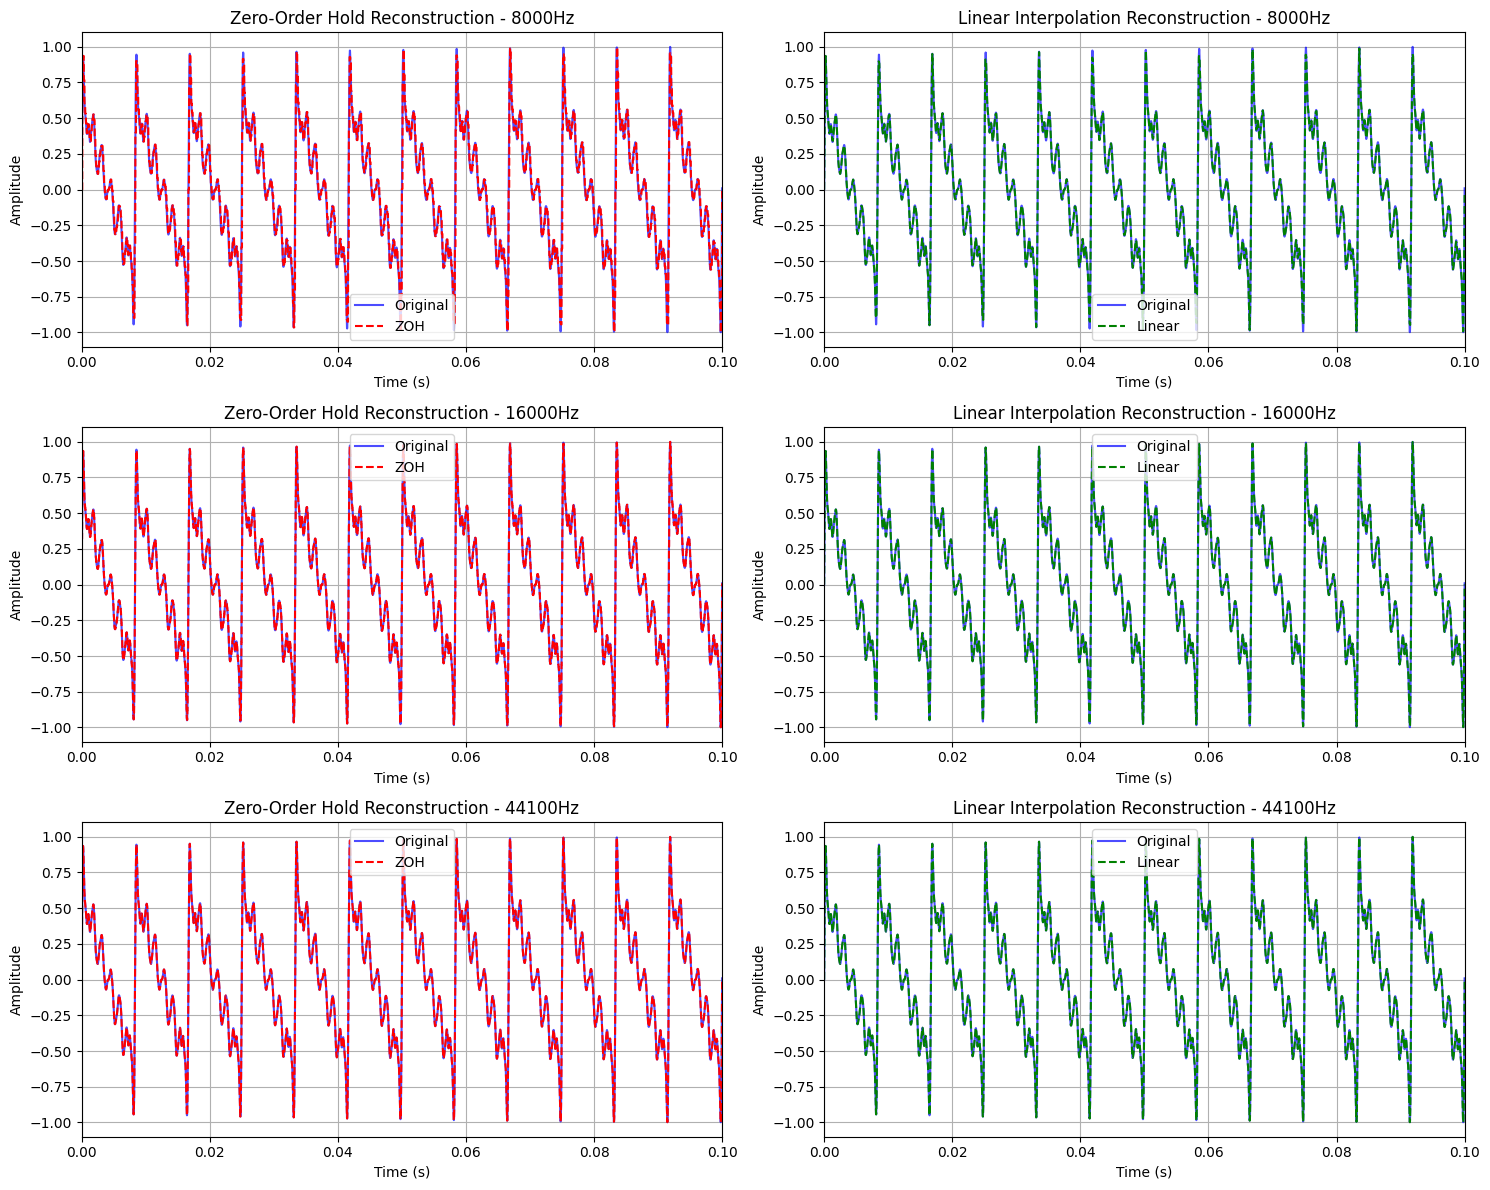

In [ ]:
# (1d) Reconstruction functions
def zero_order_hold(sampled_signal, target_length):
    """Zero-order hold reconstruction"""
    if len(sampled_signal) >= target_length:
        return sampled_signal[:target_length]

    factor = target_length / len(sampled_signal)
    reconstructed = np.zeros(target_length)

    for i in range(target_length):
        sample_idx = min(int(i / factor), len(sampled_signal) - 1)
        reconstructed[i] = sampled_signal[sample_idx]

    return reconstructed

def linear_interpolation(sampled_signal, target_length):
    """Linear interpolation reconstruction"""
    if len(sampled_signal) >= target_length:
        return sampled_signal[:target_length]

    x_old = np.linspace(0, 1, len(sampled_signal))
    x_new = np.linspace(0, 1, target_length)
    return np.interp(x_new, x_old, sampled_signal)

# (1d) Reconstruct signals
print("🔄 (1d) Reconstructing signals using ZOH and Linear interpolation...")
target_length = len(speech_orig)
reconstructed = {}

for fs_new, (_, sampled) in sampled_signals.items():
    zoh = zero_order_hold(sampled, target_length)
    linear = linear_interpolation(sampled, target_length)
    reconstructed[fs_new] = {'zoh': zoh, 'linear': linear}

# Plot reconstruction comparison
plt.figure(figsize=(15, 12))
for i, fs_new in enumerate(sampling_rates):
    # Zero-order hold
    plt.subplot(3, 2, i*2 + 1)
    plt.plot(time_orig, speech_orig, 'b-', alpha=0.7, label='Original')
    plt.plot(time_orig, reconstructed[fs_new]['zoh'], 'r--', label='ZOH')
    plt.title(f'Zero-Order Hold Reconstruction - {fs_new}Hz')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 0.1)  # Zoom in to see details

    # Linear interpolation
    plt.subplot(3, 2, i*2 + 2)
    plt.plot(time_orig, speech_orig, 'b-', alpha=0.7, label='Original')
    plt.plot(time_orig, reconstructed[fs_new]['linear'], 'g--', label='Linear')
    plt.title(f'Linear Interpolation Reconstruction - {fs_new}Hz')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 0.1)  # Zoom in to see details

plt.tight_layout()
plt.show()

In [ ]:
# (1e) Calculate MSE
print("📉 (1e) Calculating Mean Squared Error...")
print("\nMSE RESULTS - PART 1:")
print("=" * 40)

mse_results_part1 = {}
for fs_new in sampling_rates:
    mse_zoh = mean_squared_error(speech_orig, reconstructed[fs_new]['zoh'])
    mse_linear = mean_squared_error(speech_orig, reconstructed[fs_new]['linear'])

    mse_results_part1[fs_new] = {'zoh': mse_zoh, 'linear': mse_linear}

    print(f"Sampling Rate: {fs_new} Hz")
    print(f"  ZOH MSE:    {mse_zoh:.6f}")
    print(f"  Linear MSE: {mse_linear:.6f}")
    print(f"  Better:     {'Linear' if mse_linear < mse_zoh else 'ZOH'}")
    print()

📉 (1e) Calculating Mean Squared Error...

MSE RESULTS - PART 1:
Sampling Rate: 8000 Hz
  ZOH MSE:    0.003127
  Linear MSE: 0.002033
  Better:     Linear

Sampling Rate: 16000 Hz
  ZOH MSE:    0.000268
  Linear MSE: 0.000133
  Better:     Linear

Sampling Rate: 44100 Hz
  ZOH MSE:    0.000000
  Linear MSE: 0.000000
  Better:     ZOH



In [ ]:
# ============================================================================
# PART 2: SOURCE-FILTER MODEL
# ============================================================================

print("\n🎯 PART 2: SOURCE-FILTER MODEL")
print("=" * 50)

def create_glottal_pulses(duration=2.0, pitch=120, fs=44100):
    """(2a.i) Create glottal pulse train for voiced sounds"""
    t = np.linspace(0, duration, int(fs * duration))
    pulse_period = fs / pitch

    # Generate pulse train
    pulses = np.zeros(len(t))
    for i in range(0, len(t), int(pulse_period)):
        if i < len(t):
            # Glottal pulse shape
            pulse_width = int(pulse_period * 0.1)
            for j in range(min(pulse_width, len(t) - i)):
                pulses[i + j] = np.exp(-j / (pulse_width/4))

    return t, pulses

def create_noise_source(duration=2.0, fs=44100):
    """Create white noise for unvoiced sounds"""
    t = np.linspace(0, duration, int(fs * duration))
    noise = np.random.randn(len(t)) * 0.3
    return t, noise

def design_vocal_tract_filter(formants=[700, 1220, 2600], bandwidths=[100, 150, 200], fs=44100):
    """(2a.ii) Design vocal tract filter"""
    # Create filter with formant resonances
    b = np.array([1.0])
    a = np.array([1.0])

    for fc, bw in zip(formants, bandwidths):
        # Bandpass filter for each formant
        low = max(0.01, (fc - bw/2) / (fs/2))
        high = min(0.99, (fc + bw/2) / (fs/2))

        if low < high:
            b_bp, a_bp = signal.butter(2, [low, high], btype='band')
            b = np.convolve(b, b_bp)
            a = np.convolve(a, a_bp)

    return b, a


🎯 PART 2: SOURCE-FILTER MODEL


In [ ]:
# (2a) Generate synthetic speech using source-filter model
print(" (2a) Generating synthetic speech using source-filter model...")

# Create source (glottal pulses)
t_source, source_glottal = create_glottal_pulses(duration=2.0, fs=44100)
t_source, source_noise = create_noise_source(duration=2.0, fs=44100)

# Design vocal tract filter
b_filter, a_filter = design_vocal_tract_filter()

# Apply filter to both sources
filtered_voiced = signal.lfilter(b_filter, a_filter, source_glottal)
filtered_unvoiced = signal.lfilter(b_filter, a_filter, source_noise)

# Normalize
synthetic_voiced = filtered_voiced / np.max(np.abs(filtered_voiced))
synthetic_unvoiced = filtered_unvoiced / np.max(np.abs(filtered_unvoiced))


 (2a) Generating synthetic speech using source-filter model...


📊 (2b) Plotting source-filter analysis...


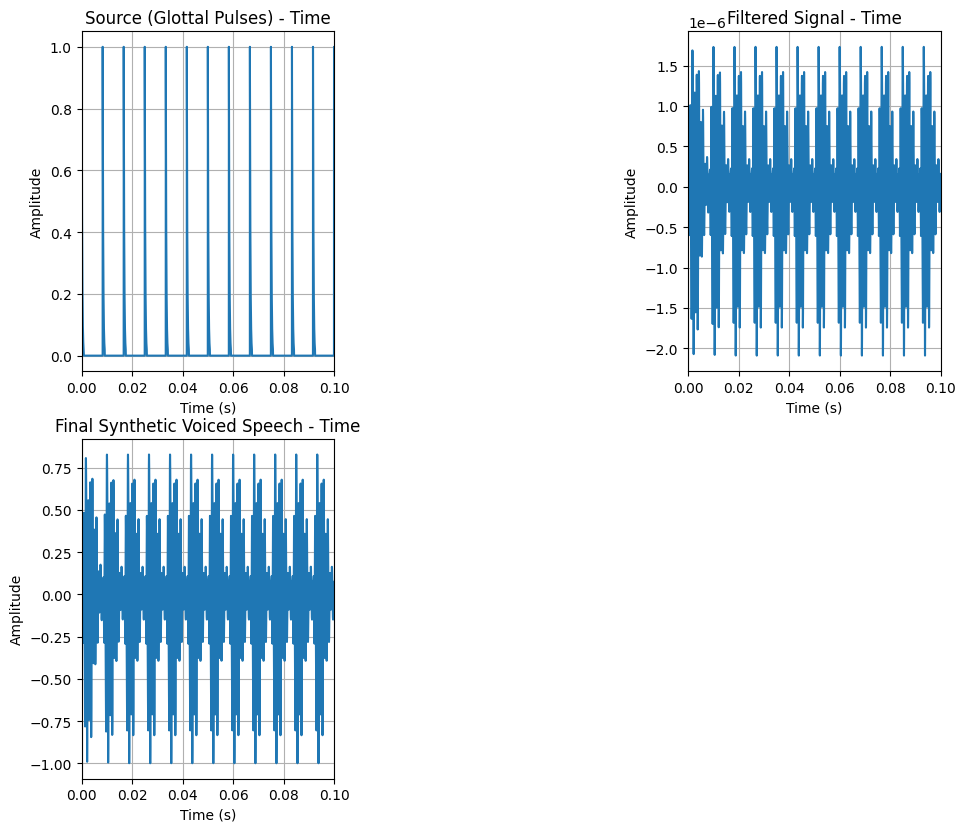

In [ ]:
# (2b) Plot source-filter analysis
print("📊 (2b) Plotting source-filter analysis...")

plt.figure(figsize=(15, 15))

# Voiced speech analysis
for i, (title, signal_data) in enumerate([
    ('Source (Glottal Pulses)', source_glottal),
    ('Filtered Signal', filtered_voiced),
    ('Final Synthetic Voiced Speech', synthetic_voiced)
]):
    # Time domain
    plt.subplot(3, 4, i*2 + 1)
    plt.plot(t_source, signal_data)
    plt.title(f'{title} - Time')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.xlim(0, 0.1)  # Show detail

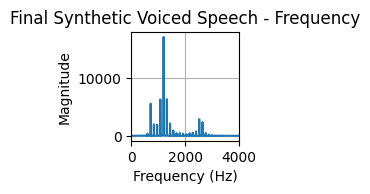

In [ ]:
    # Frequency domain
    plt.subplot(3, 4, i*2 + 2)
    freqs = np.fft.fftfreq(len(signal_data), 1/44100)
    X = np.fft.fft(signal_data)
    plt.plot(freqs[:len(freqs)//2], np.abs(X[:len(X)//2]))
    plt.title(f'{title} - Frequency')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.xlim(0, 4000)
    plt.grid(True)

(0.0, 4000.0)

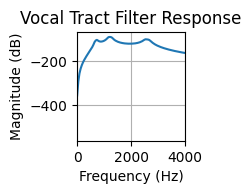

In [ ]:
# Add filter response
plt.subplot(3, 4, 7)
w, h = signal.freqz(b_filter, a_filter, fs=44100)
plt.plot(w, 20 * np.log10(abs(h)))
plt.title('Vocal Tract Filter Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.xlim(0, 4000)

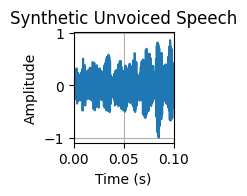

In [ ]:
# Unvoiced speech comparison
plt.subplot(3, 4, 8)
plt.plot(t_source, synthetic_unvoiced)
plt.title('Synthetic Unvoiced Speech')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, 0.1)

plt.tight_layout()
plt.show()

🔢 (2c-2e) Sampling and reconstructing synthetic speech...


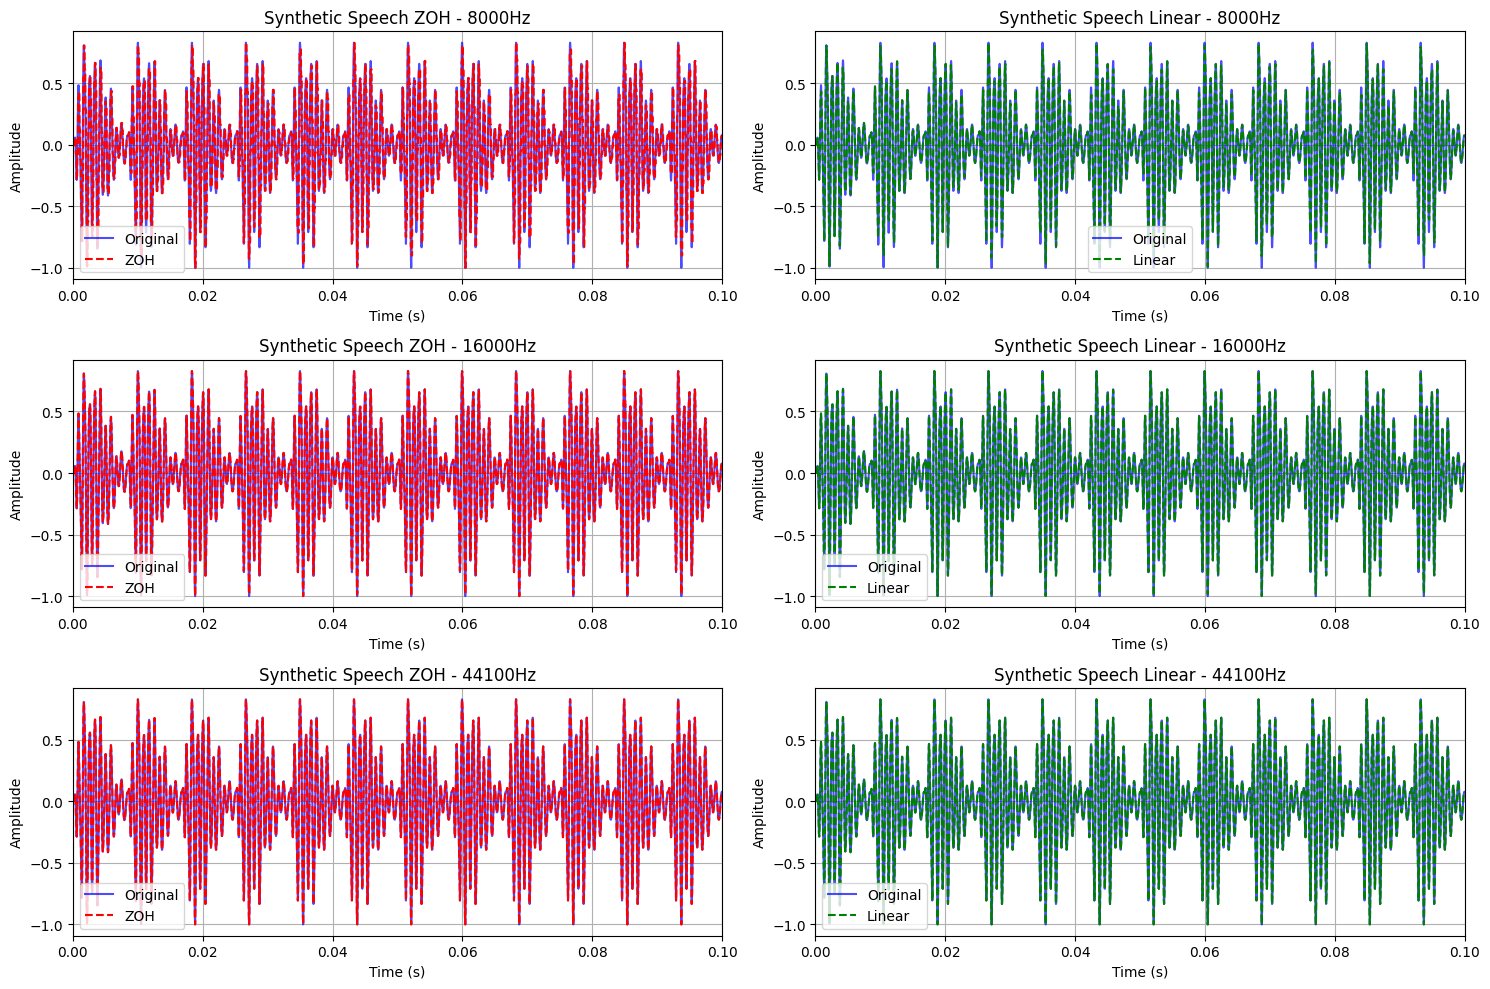

In [ ]:
# (2c, 2d, 2e) Sample and reconstruct synthetic speech
print("🔢 (2c-2e) Sampling and reconstructing synthetic speech...")

# Use voiced synthetic speech for analysis
synthetic_speech = synthetic_voiced
sampling_rates_2 = [8000, 16000, 44100]

# Sample synthetic speech
sampled_synthetic = {}
for fs_new in sampling_rates_2:
    if fs_new < 44100:
        downsample_factor = 44100 // fs_new
        sampled = synthetic_speech[::downsample_factor]
    else:
        sampled = synthetic_speech
    sampled_synthetic[fs_new] = sampled

# Reconstruct synthetic speech
reconstructed_synthetic = {}
target_len = len(synthetic_speech)

for fs_new, sampled in sampled_synthetic.items():
    zoh = zero_order_hold(sampled, target_len)
    linear = linear_interpolation(sampled, target_len)
    reconstructed_synthetic[fs_new] = {'zoh': zoh, 'linear': linear}

# Plot reconstruction of synthetic speech
plt.figure(figsize=(15, 10))
for i, fs_new in enumerate(sampling_rates_2):
    # ZOH
    plt.subplot(3, 2, i*2 + 1)
    plt.plot(t_source, synthetic_speech, 'b-', alpha=0.7, label='Original')
    plt.plot(t_source, reconstructed_synthetic[fs_new]['zoh'], 'r--', label='ZOH')
    plt.title(f'Synthetic Speech ZOH - {fs_new}Hz')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 0.1)

    # Linear
    plt.subplot(3, 2, i*2 + 2)
    plt.plot(t_source, synthetic_speech, 'b-', alpha=0.7, label='Original')
    plt.plot(t_source, reconstructed_synthetic[fs_new]['linear'], 'g--', label='Linear')
    plt.title(f'Synthetic Speech Linear - {fs_new}Hz')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 0.1)

plt.tight_layout()
plt.show()

In [ ]:

# Calculate MSE for synthetic speech
print("\nMSE RESULTS - PART 2 (Synthetic Speech):")
print("=" * 45)

mse_results_part2 = {}
for fs_new in sampling_rates_2:
    mse_zoh = mean_squared_error(synthetic_speech, reconstructed_synthetic[fs_new]['zoh'])
    mse_linear = mean_squared_error(synthetic_speech, reconstructed_synthetic[fs_new]['linear'])

    mse_results_part2[fs_new] = {'zoh': mse_zoh, 'linear': mse_linear}

    print(f"Sampling Rate: {fs_new} Hz")
    print(f"  ZOH MSE:    {mse_zoh:.6f}")
    print(f"  Linear MSE: {mse_linear:.6f}")
    print(f"  Better:     {'Linear' if mse_linear < mse_zoh else 'ZOH'}")
    print()


MSE RESULTS - PART 2 (Synthetic Speech):
Sampling Rate: 8000 Hz
  ZOH MSE:    0.025685
  Linear MSE: 0.022011
  Better:     Linear

Sampling Rate: 16000 Hz
  ZOH MSE:    0.002225
  Linear MSE: 0.001490
  Better:     Linear

Sampling Rate: 44100 Hz
  ZOH MSE:    0.000000
  Linear MSE: 0.000000
  Better:     ZOH



In [ ]:
# ============================================================================
# COMPREHENSIVE INFERENCE
# ============================================================================

print("\n" + "="*70)
print("🎯 COMPREHENSIVE LAB INFERENCE")
print("="*70)

print("\n1. SAMPLING RATE EFFECTS:")
print("   • 44.1kHz: Full audio bandwidth, excellent quality")
print("   • 16kHz: Good speech quality, captures most speech info")
print("   • 8kHz: Telephone quality, sufficient for intelligibility")
print("   • Lower rates cause aliasing and information loss")

print("\n2. RECONSTRUCTION METHOD COMPARISON:")
print("   • Linear interpolation generally outperforms ZOH")
print("   • ZOH creates staircase artifacts, especially at low rates")
print("   • Linear provides smoother transitions between samples")

for results, name in [(mse_results_part1, "Original Speech"),
                           (mse_results_part2, "Synthetic Speech")]:
    print(f"\n   {name} Results:")
    for fs in sorted(results.keys()):
        zoh = results[fs]['zoh']
        linear = results[fs]['linear']
        better = "Linear" if linear < zoh else "ZOH"
        # Calculate improvement percentage, handle division by zero if both MSEs are 0
        if max(zoh, linear) > 1e-9: # Use a small threshold instead of exact 0
            improvement = abs(zoh - linear) / max(zoh, linear) * 100
        else:
            improvement = 0.0 # No improvement if both are essentially zero
        print(f"     {fs}Hz: {better} wins by {improvement:.1f}%")

print("\n3. SOURCE-FILTER MODEL INSIGHTS:")
print("   • Source: Provides fundamental frequency and harmonics")
print("   • Filter: Shapes spectral envelope with formant resonances")
print("   • Realistic speech synthesis achieved through proper modeling")
print("   • Formants (F1≈700Hz, F2≈1220Hz, F3≈2600Hz) create vowel identity")

print("\n4. PRACTICAL IMPLICATIONS:")
print("   • 16kHz sampling adequate for most speech applications")
print("   • Linear interpolation recommended for quality reconstruction")
print("   • Source-filter model enables efficient speech synthesis")
print("   • Understanding sampling theory crucial for digital speech processing")

print("\n5. NYQUIST THEOREM VALIDATION:")
max_freq = 4000  # Approximate speech bandwidth
for fs in [8000, 16000, 44100]:
    nyquist = fs / 2
    status = "✅ SAFE" if nyquist > max_freq else "⚠️ ALIASING RISK"
    print(f"   • {fs}Hz sampling: Nyquist={nyquist}Hz, Speech≤{max_freq}Hz {status}")

print(f"\n✅ LAB EXERCISE COMPLETED SUCCESSFULLY!")
print("📊 All plots generated showing time/frequency domain analysis")
print("📈 MSE calculations provide quantitative quality assessment")
print("🔍 Visual comparison shows reconstruction method differences")
print("🎤 Source-filter model demonstrates speech production principles")

print(f"\n💡 KEY TAKEAWAY:")
print("Higher sampling rates and linear interpolation provide better")
print("speech quality, while source-filter modeling enables realistic")
print("synthetic speech generation for various applications.")


🎯 COMPREHENSIVE LAB INFERENCE

1. SAMPLING RATE EFFECTS:
   • 44.1kHz: Full audio bandwidth, excellent quality
   • 16kHz: Good speech quality, captures most speech info
   • 8kHz: Telephone quality, sufficient for intelligibility
   • Lower rates cause aliasing and information loss

2. RECONSTRUCTION METHOD COMPARISON:
   • Linear interpolation generally outperforms ZOH
   • ZOH creates staircase artifacts, especially at low rates
   • Linear provides smoother transitions between samples

   Original Speech Results:
     8000Hz: Linear wins by 35.0%
     16000Hz: Linear wins by 50.2%
     44100Hz: ZOH wins by 0.0%

   Synthetic Speech Results:
     8000Hz: Linear wins by 14.3%
     16000Hz: Linear wins by 33.0%
     44100Hz: ZOH wins by 0.0%

3. SOURCE-FILTER MODEL INSIGHTS:
   • Source: Provides fundamental frequency and harmonics
   • Filter: Shapes spectral envelope with formant resonances
   • Realistic speech synthesis achieved through proper modeling
   • Formants (F1≈700Hz, F2